# 04. Feature Validation

Notebook này đánh giá mức độ liên quan và khả năng đóng góp của các biến nghiên cứu đối với mục tiêu dự đoán Digital Burnout. Các phương pháp thống kê và Feature Importance được sử dụng để xác định tập đặc trưng phù hợp trước khi xây dựng mô hình Machine Learning trong Notebook 05.

# 0. Set Up

Phần này nhập các thư viện cần thiết và thiết lập các cấu hình chung phục vụ cho quá trình Feature Validation.

In [53]:
# Thư viện chuẩn

from pathlib import Path
import os
import warnings

# Xử lý dữ liệu

import numpy as np
import pandas as pd

# Trực quan hóa

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Validation

from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif

# Feature Importance

from sklearn.ensemble import RandomForestClassifier

In [3]:
# Thiết lập cấu hình

warnings.filterwarnings(
    
    "ignore"
    
)

RANDOM_STATE = 42

np.random.seed(
    
    RANDOM_STATE
    
)

plt.style.use(
    
    "default"
    
)

pd.set_option(
    
    "display.max_columns",
    None
    
)

pd.set_option(

    "display.float_format",
    "{:.4f}".format
)

In [4]:
# Khai báo đường dẫn dữ liệu

input_path = (

    "../../data/processed/international_dataset/"
    "digital_burnout_cleaned.csv"

)

output_directory = (

    "../../data/processed/international_dataset"

)

os.makedirs(

    output_directory,
    exist_ok=True

)

# 1. Load Cleaned Dataset

Phần này đọc bộ dữ liệu đã được làm sạch từ Notebook 02, kiểm tra cấu trúc dữ liệu và xác nhận dữ liệu sẵn sàng cho quá trình Feature Validation.

In [5]:
# Đọc bộ dữ liệu

df = pd.read_csv(

    input_path

)

In [6]:
# Hiển thị kích thước bộ dữ liệu

print(
    f"Dataset Shape: {df.shape}"
)

display(
    df.head()
)

Dataset Shape: (5000000, 34)


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_score,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8000,5.0000,1.2000,41,112,49,1,3,6.0000,67,92,2,5.9000,10,6,1.6000,10,5,2.8000,3,4,8.0000,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3000,2.2000,2.4000,119,168,153,1,9,4.6000,75,74,3,5.6000,7,5,1.1000,5,10,3.2000,7,6,5.0000,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5000,4.6000,1.0000,121,199,234,1,5,3.0000,70,96,7,5.5000,8,6,1.1000,4,1,2.3000,9,6,8.0000,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6000,1.2000,0.1000,85,122,177,1,9,2.9000,107,60,3,6.1000,5,1,1.7000,1,4,3.8000,10,5,6.0000,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3000,1.6000,1.9000,221,73,91,1,9,2.8000,72,73,9,7.9000,1,3,1.8000,4,8,3.0000,1,1,4.0000,7,9,7,Focused,64,89,High


In [7]:
# Kiểm tra kiểu dữ liệu

display(

    df.dtypes.to_frame(
        name="Data Type"
    )

)

,Data Type
user_id,int64
age,int64
occupation,object
work_mode,object
device_usage_type,object
daily_screen_time,float64
social_media_hours,float64
doomscrolling_duration,float64
app_switch_frequency,int64
notification_count,int64


In [8]:
# Kiểm tra giá trị thiếu

missing_summary = (

    df
    .isna()
    .sum()
    .to_frame(
        name="Missing Values"
    )

)

display(
    missing_summary
)

,Missing Values
user_id,0
age,0
occupation,0
work_mode,0
device_usage_type,0
daily_screen_time,0
social_media_hours,0
doomscrolling_duration,0
app_switch_frequency,0
notification_count,0


In [9]:
# Tổng hợp thông tin bộ dữ liệu

dataset_information = pd.DataFrame({

    "Metric": [

        "Number of Samples",
        "Number of Features",
        "Missing Values",
        "Duplicate Records"

    ],

    "Value": [

        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum())

    ]

})

display(

    dataset_information

)

,Metric,Value
0,Number of Samples,5000000
1,Number of Features,34
2,Missing Values,0
3,Duplicate Records,0


# 2. Feature Validation Configuration

Phần này định nghĩa các nhóm biến nghiên cứu, biến mục tiêu và các tham số sử dụng trong quá trình Feature Validation. Các cấu hình này sẽ được sử dụng thống nhất trong toàn bộ notebook.

In [10]:
# Xây dựng các nhóm biến nghiên cứu

construct_groups = {

    "Burnout Symptoms": [

        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue"

    ],

    "Digital Exposure": [

        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"

    ],

    "Cognitive Performance": [

        "concentration_score",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level"

    ],

    "Sleep & Recovery": [

        "sleep_hours",
        "sleep_quality"

    ],

    "Context Variables": [

        "work_mode",
        "device_usage_type"

    ]

}

In [11]:
# Xây dựng danh sách biến số

numerical_features = (

    construct_groups["Burnout Symptoms"]
    +
    construct_groups["Digital Exposure"]
    +
    construct_groups["Cognitive Performance"]
    +
    construct_groups["Sleep & Recovery"]

)

# Xây dựng danh sách biến phân loại

categorical_features = (

    construct_groups["Context Variables"]

)

In [12]:
# Khai báo biến mục tiêu

target_variable = "burnout_risk"

In [13]:
# Thiết lập cấu hình Feature Validation

correlation_method = "pearson"

anova_significance_level = 0.05

chi_square_significance_level = 0.05

mutual_information_random_state = RANDOM_STATE

random_forest_estimators = 100

random_forest_random_state = RANDOM_STATE

In [14]:
# Tổng hợp cấu hình Feature Validation

validation_configuration = pd.DataFrame({

    "Configuration": [

        "Numerical Features",
        "Categorical Features",
        "Target Variable",
        "Correlation Method",
        "Significance Level",
        "Random Forest Estimators"

    ],

    "Value": [

        len(numerical_features),
        len(categorical_features),
        target_variable,
        correlation_method,
        anova_significance_level,
        random_forest_estimators

    ]

})

display(

    validation_configuration

)

,Configuration,Value
0,Numerical Features,17
1,Categorical Features,2
2,Target Variable,burnout_risk
3,Correlation Method,pearson
4,Significance Level,0.0500
5,Random Forest Estimators,100


In [15]:
# Tạo biến mục tiêu phục vụ bài toán phân loại

df["burnout_risk"] = pd.qcut(

    df["burnout_score"],
    q=3,
    labels=False

)

# 3. Statistical Feature Validation

Phần này đánh giá mức độ liên quan giữa các biến nghiên cứu và biến mục tiêu thông qua các phương pháp thống kê. Kết quả sẽ được sử dụng để xác định những đặc trưng có ý nghĩa trước khi xây dựng mô hình Machine Learning.

In [16]:
# Chuyển biến mục tiêu sang dạng số 

if df[target_variable].dtype == "object":

    df[target_variable] = (

        df[target_variable]
        .astype("category")
        .cat.codes

    )

## 3.1 ANOVA F-test

Đánh giá mức độ khác biệt của các biến số giữa các nhóm Burnout Risk bằng phép kiểm định ANOVA F-test.

In [17]:
# Thực hiện ANOVA F-test

f_scores, p_values = f_classif(

    df[numerical_features],
    df[target_variable]

)

anova_results = pd.DataFrame({

    "Feature": numerical_features,
    "F Score": f_scores,
    "P Value": p_values

})

anova_results = anova_results.sort_values(

    by="F Score",
    ascending=False

)

display(
    anova_results
)

,Feature,F Score,P Value
0,emotional_exhaustion,710461.5349,0.0000
1,stress_level,336232.9680,0.0000
3,daily_screen_time,98228.1097,0.0000
5,doomscrolling_duration,80691.0372,0.0000
6,late_night_device_usage,49958.5748,0.0000
15,sleep_hours,32805.6649,0.0000
7,notification_count,18341.9818,0.0000
12,deep_work_hours,4122.5818,0.0000
11,focus_sessions,2.4576,0.0856
10,concentration_score,2.1065,0.1217


In [18]:
# Đánh giá ý nghĩa thống kê

anova_results["Significant"] = (

    anova_results["P Value"]
    <
    anova_significance_level

)

display(

    anova_results

)

,Feature,F Score,P Value,Significant
0,emotional_exhaustion,710461.5349,0.0000,True
1,stress_level,336232.9680,0.0000,True
3,daily_screen_time,98228.1097,0.0000,True
5,doomscrolling_duration,80691.0372,0.0000,True
6,late_night_device_usage,49958.5748,0.0000,True
15,sleep_hours,32805.6649,0.0000,True
7,notification_count,18341.9818,0.0000,True
12,deep_work_hours,4122.5818,0.0000,True
11,focus_sessions,2.4576,0.0856,False
10,concentration_score,2.1065,0.1217,False


In [19]:
# Tổng hợp kết quả ANOVA

anova_summary = pd.DataFrame({

    "Metric": [

        "Total Numerical Features",
        "Significant Features",
        "Non-significant Features"

    ],

    "Value": [

        len(anova_results),
        anova_results["Significant"].sum(),
        (~anova_results["Significant"]).sum()

    ]
})

display(
    anova_summary
)

,Metric,Value
0,Total Numerical Features,17
1,Significant Features,8
2,Non-significant Features,9


## 3.2 Chi-square Test

Đánh giá mối liên hệ giữa các biến phân loại và Burnout Risk bằng phép kiểm định Chi-square. Những biến có giá trị p nhỏ hơn mức ý nghĩa thống kê sẽ được xem là có ảnh hưởng đáng kể đến biến mục tiêu.

In [20]:
# Thực hiện Chi-square Test

chi_square_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(

        df[feature],
        df[target_variable]

    )

    chi2_statistic, p_value, degrees_of_freedom, _ = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({

        "Feature": feature,
        "Chi-square": chi2_statistic,
        "Degrees of Freedom": degrees_of_freedom,
        "P Value": p_value

    })

chi_square_results = pd.DataFrame(
    chi_square_results
)

chi_square_results = chi_square_results.sort_values(

    by="Chi-square",
    ascending=False

)

display(
    chi_square_results
)

,Feature,Chi-square,Degrees of Freedom,P Value
1,device_usage_type,1.2696,4,0.8665
0,work_mode,0.8523,4,0.9313


In [21]:
# Đánh giá ý nghĩa thống kê

chi_square_results["Significant"] = (

    chi_square_results["P Value"]
    <
    chi_square_significance_level

)

display(
    chi_square_results
)

,Feature,Chi-square,Degrees of Freedom,P Value,Significant
1,device_usage_type,1.2696,4,0.8665,False
0,work_mode,0.8523,4,0.9313,False


In [22]:
# Tổng hợp kết quả Chi-square

chi_square_summary = pd.DataFrame({

    "Metric": [

        "Total Categorical Features",
        "Significant Features",
        "Non-significant Features"

    ],

    "Value": [

        len(chi_square_results),
        chi_square_results["Significant"].sum(),
        (~chi_square_results["Significant"]).sum()

    ]

})

display(
    chi_square_summary
)

,Metric,Value
0,Total Categorical Features,2
1,Significant Features,0
2,Non-significant Features,2


In [23]:
# Hiển thị bảng chéo của từng biến phân loại

for feature in categorical_features:

    print()
    print(f"Feature: {feature}")

    display(

        pd.crosstab(

            df[feature],
            df[target_variable]

        )

    )


Feature: work_mode


burnout_risk,0,1,2
work_mode,,,
Hybrid,607687,562649,577829
Office,347839,321984,331238
Remote,782008,724901,743865



Feature: device_usage_type


burnout_risk,0,1,2
device_usage_type,,,
Balanced,607562,563634,578687
Entertainment-Centric,521617,483065,496056
Work-Centric,608355,562835,578189


## 3.3 Mutual Information

Đánh giá lượng thông tin mà mỗi đặc trưng cung cấp cho việc dự đoán Burnout Risk bằng Mutual Information.

Do bộ dữ liệu có kích thước rất lớn, phương pháp này được thực hiện trên một tập mẫu ngẫu nhiên nhằm giảm thời gian tính toán trong khi vẫn đảm bảo tính đại diện của dữ liệu.

In [24]:
# Sao chép tập đặc trưng

feature_matrix = df[

    numerical_features +
    categorical_features

].copy()

In [25]:
# Mã hóa các biến phân loại

for feature in categorical_features:

    feature_matrix[feature] = (

        feature_matrix[feature]
        .astype("category")
        .cat.codes

    )

In [26]:
# Lấy mẫu dữ liệu phục vụ Mutual Information

mutual_information_sample_size = 500_000

sample_size = min(

    mutual_information_sample_size,
    len(feature_matrix)

)

sample_indices = np.random.RandomState(
    RANDOM_STATE
).choice(

    feature_matrix.index,
    size=sample_size,
    replace=False

)

feature_matrix_sample = feature_matrix.loc[
    sample_indices
]

target_sample = df.loc[

    sample_indices,
    target_variable

]

In [27]:
# Kiểm tra kích thước dữ liệu mẫu

print(
    f"Sample Size: {len(feature_matrix_sample):,}"
)

Sample Size: 500,000


In [28]:
# Tính Mutual Information

mi_scores = mutual_info_classif(

    feature_matrix_sample,
    target_sample,
    random_state=RANDOM_STATE

)

In [29]:
# Tổng hợp kết quả Mutual Information

mutual_information_results = pd.DataFrame({

    "Feature": feature_matrix.columns,
    "Mutual Information": mi_scores

})

mutual_information_results = (

    mutual_information_results

    .sort_values(

        by="Mutual Information",
        ascending=False

    )

    .reset_index(
        drop=True
    )

)

display(
    mutual_information_results
)

,Feature,Mutual Information
0,emotional_exhaustion,0.1255
1,stress_level,0.0665
2,late_night_device_usage,0.0438
3,daily_screen_time,0.0205
4,work_mode,0.0190
5,device_usage_type,0.0163
6,doomscrolling_duration,0.0155
7,sleep_hours,0.0063
8,focus_sessions,0.0054
9,notification_count,0.0044


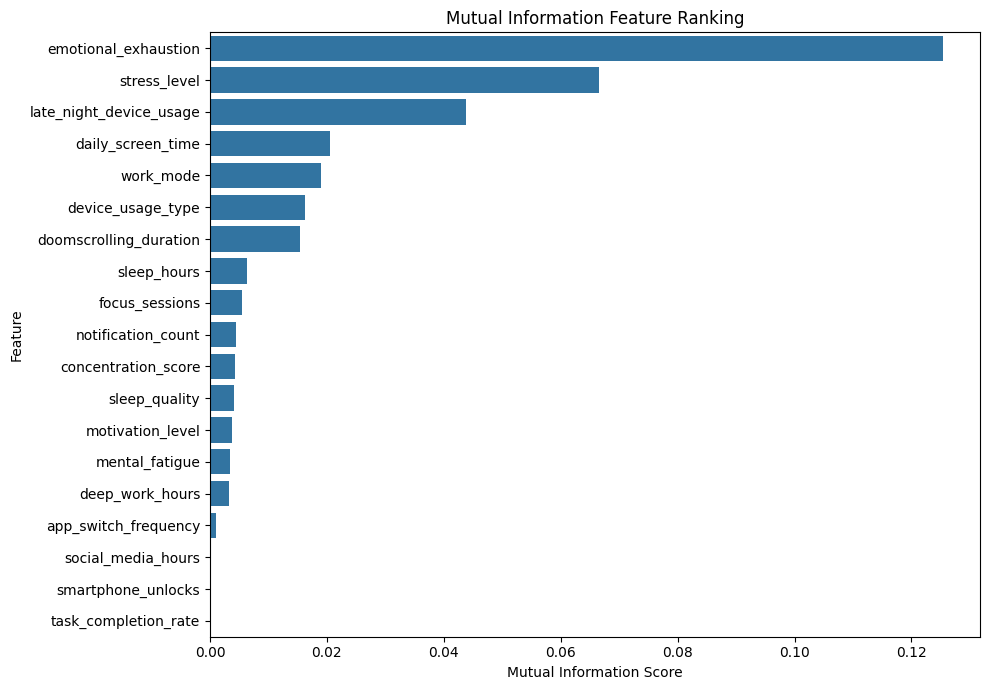

In [30]:
# Trực quan hóa Mutual Information

plt.figure(
    figsize=(10, 7)
)

sns.barplot(

    data=mutual_information_results,
    x="Mutual Information",
    y="Feature"

)

plt.title(
    "Mutual Information Feature Ranking"
)

plt.xlabel(
    "Mutual Information Score"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [31]:
# Tổng hợp kết quả Mutual Information

mutual_information_summary = pd.DataFrame({

    "Metric": [

        "Sample Size",
        "Total Features",
        "Features with Information",
        "Features without Information"

    ],

    "Value": [

        sample_size,
        len(mutual_information_results),
        (
            mutual_information_results["Mutual Information"]
            >
            0
        ).sum(),

        (

            mutual_information_results["Mutual Information"]
            ==
            0

        ).sum()

    ]

})

display(

    mutual_information_summary
)

,Metric,Value
0,Sample Size,500000
1,Total Features,19
2,Features with Information,17
3,Features without Information,2


# 4. Feature Importance Assessment

Phần này đánh giá mức độ quan trọng của từng đặc trưng bằng Random Forest Feature Importance. Kết quả sẽ được kết hợp với các phương pháp thống kê ở Section 3 để xây dựng bảng xếp hạng đặc trưng.

## 4.1 Random Forest Feature Importance

Huấn luyện mô hình Random Forest trên tập dữ liệu mẫu và đánh giá mức độ đóng góp của từng đặc trưng đối với việc dự đoán Burnout Risk.

In [32]:
# Khởi tạo mô hình Random Forest

random_forest_model = RandomForestClassifier(

    n_estimators=random_forest_estimators,
    random_state=random_forest_random_state,
    n_jobs=-1

)

# Huấn luyện mô hình

random_forest_model.fit(

    feature_matrix_sample,
    target_sample

)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [33]:
# Tính Feature Importance

feature_importance_results = pd.DataFrame({

    "Feature": feature_matrix_sample.columns,
    "Feature Importance": random_forest_model.feature_importances_

})

feature_importance_results = (
    
    feature_importance_results
    
    .sort_values(

        by="Feature Importance",
        ascending=False

    )

    .reset_index(
        drop=True
    )

)

display(
    feature_importance_results
)

,Feature,Feature Importance
0,emotional_exhaustion,0.1372
1,stress_level,0.0861
2,daily_screen_time,0.0762
3,notification_count,0.0650
4,doomscrolling_duration,0.0626
5,smartphone_unlocks,0.0600
6,app_switch_frequency,0.0598
7,sleep_hours,0.0587
8,deep_work_hours,0.0556
9,social_media_hours,0.0553


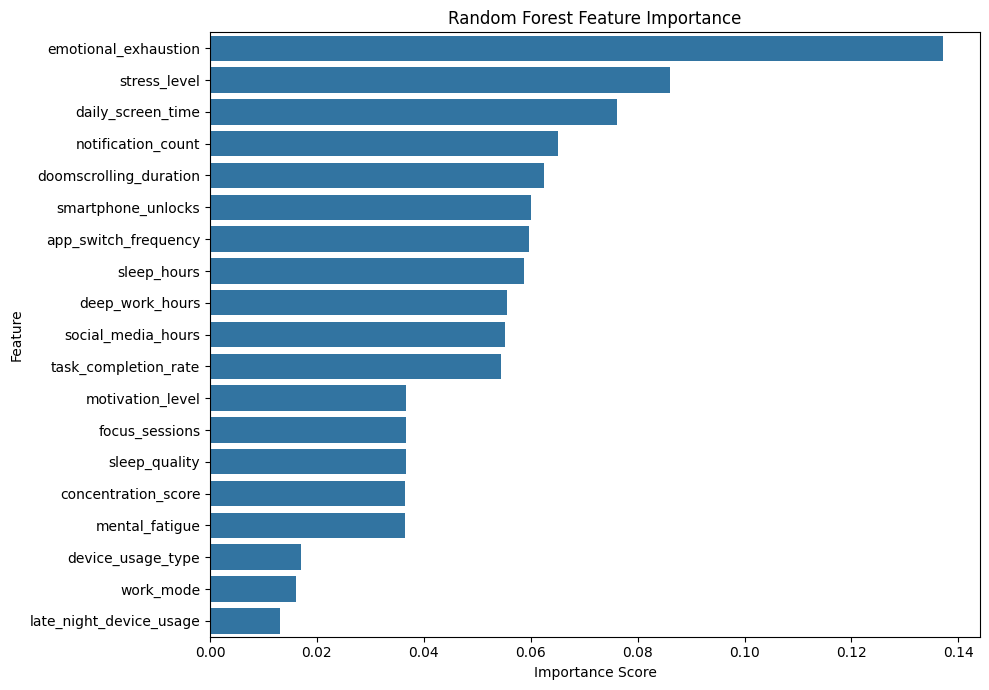

In [34]:
# Trực quan hóa Feature Importance

plt.figure(
    figsize=(10, 7)
)

sns.barplot(

    data=feature_importance_results,
    x="Feature Importance",
    y="Feature"

)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [35]:
# Tổng hợp Feature Importance

feature_importance_summary = pd.DataFrame({

    "Metric": [

        "Training Samples",
        "Total Features"

    ],

    "Value": [

        len(feature_matrix_sample),
        len(feature_importance_results)

    ]

})

display(
    feature_importance_summary
)

,Metric,Value
0,Training Samples,500000
1,Total Features,19


## 4.2 Overall Feature Ranking

Chuẩn hóa kết quả từ ANOVA F-test, Mutual Information và Random Forest Feature Importance về cùng một thang điểm để xây dựng bảng xếp hạng đặc trưng tổng hợp.

In [36]:
# Chuẩn hóa điểm ANOVA

anova_scores = (

    anova_results[

        [
            "Feature",
            "F Score"
        ]

    ]
    .copy()
)

anova_scores["ANOVA Score"] = (

    anova_scores["F Score"]

    .rank(
        pct=True
    )
    *
    100

)

In [37]:
# Chuẩn hóa điểm Mutual Information

mutual_information_scores = (

    mutual_information_results[

        [
            "Feature",
            "Mutual Information"
        ]

    ]
    
    .copy()

)

mutual_information_scores["MI Score"] = (

    mutual_information_scores["Mutual Information"]

    .rank(
        pct=True
    )
    *
    100

)

In [38]:
# Chuẩn hóa điểm Random Forest

random_forest_scores = (

    feature_importance_results[

        [
            "Feature",
            "Feature Importance"
        ]

    ]
    .copy()
)

random_forest_scores["RF Score"] = (

    random_forest_scores["Feature Importance"]

    .rank(
        pct=True
    )
    *
    100

)

In [39]:
# Tổng hợp kết quả đánh giá đặc trưng

feature_validation_summary = (

    anova_scores

    .merge(

        mutual_information_scores,
        on="Feature"

    )

    .merge(

        random_forest_scores,
        on="Feature"

    )

)

In [40]:
# Tính điểm tổng hợp

feature_validation_summary["Final Score"] = (

    feature_validation_summary[

        [

            "ANOVA Score",
            "MI Score",
            "RF Score"

        ]

    ]

    .mean(
        axis=1
    )

)

In [41]:
# Xếp hạng đặc trưng

feature_validation_summary = (

    feature_validation_summary

    .sort_values(

        by="Final Score",
        ascending=False

    )

    .reset_index(
        drop=True
    )

)

feature_validation_summary.insert(

    0,
    "Rank",
    range(

        1,
        len(
            feature_validation_summary
        )
        +
        1

    )

)

display(
    feature_validation_summary
)

,Rank,Feature,F Score,ANOVA Score,Mutual Information,MI Score,Feature Importance,RF Score,Final Score
0,1,emotional_exhaustion,710461.5349,100.0000,0.1255,100.0000,0.1372,100.0000,100.0000
1,2,stress_level,336232.9680,94.1176,0.0665,94.7368,0.0861,94.7368,94.5304
2,3,daily_screen_time,98228.1097,88.2353,0.0205,84.2105,0.0762,89.4737,87.3065
3,4,doomscrolling_duration,80691.0372,82.3529,0.0155,68.4211,0.0626,78.9474,76.5738
4,5,notification_count,18341.9818,64.7059,0.0044,52.6316,0.0650,84.2105,67.1827
5,6,sleep_hours,32805.6649,70.5882,0.0063,63.1579,0.0587,63.1579,65.6347
6,7,late_night_device_usage,49958.5748,76.4706,0.0438,89.4737,0.0130,5.2632,57.0691
7,8,focus_sessions,2.4576,52.9412,0.0054,57.8947,0.0367,36.8421,49.2260
8,9,deep_work_hours,4122.5818,58.8235,0.0032,26.3158,0.0556,57.8947,47.6780
9,10,app_switch_frequency,0.7694,35.2941,0.0010,21.0526,0.0598,68.4211,41.5893


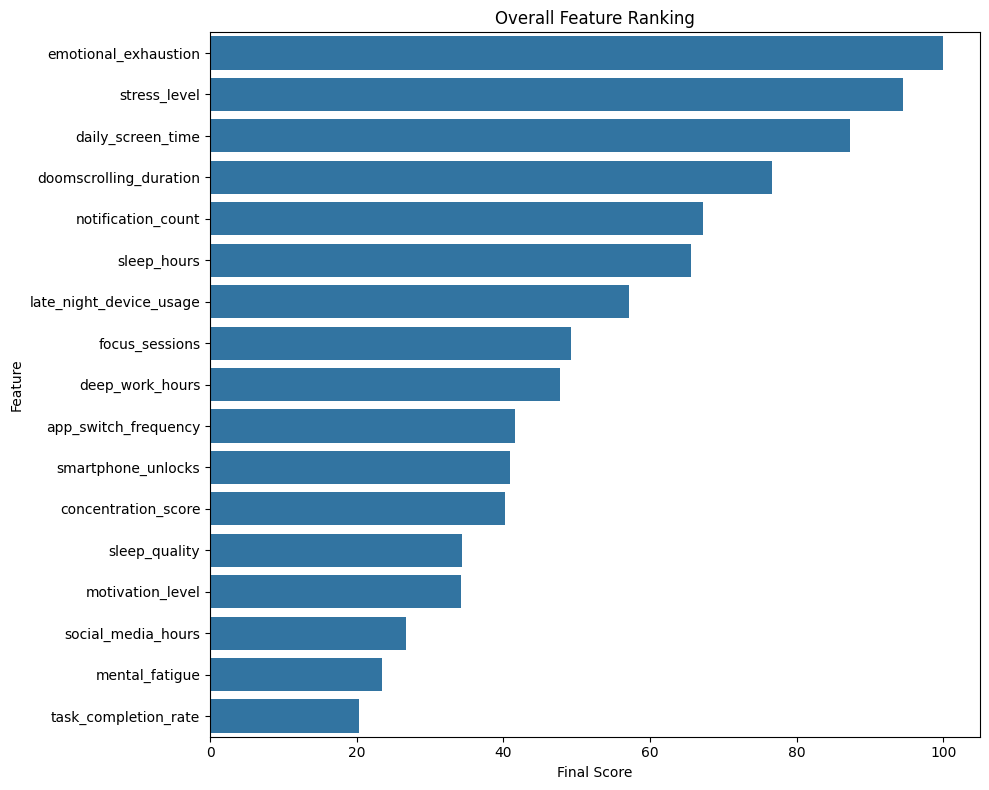

In [42]:
# Trực quan hóa điểm tổng hợp

plt.figure(
    figsize=(10, 8)
)

sns.barplot(

    data=feature_validation_summary,
    x="Final Score",
    y="Feature"

)

plt.title(
    "Overall Feature Ranking"
)

plt.xlabel(
    "Final Score"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [64]:
print(len(feature_validation_summary))
display(feature_validation_summary)

17


,Rank,Feature,F Score,ANOVA Score,Mutual Information,MI Score,Feature Importance,RF Score,Final Score,Indicator Level
0,1,emotional_exhaustion,710461.5349,100.0000,0.1255,100.0000,0.1372,100.0000,100.0000,Strong
1,2,stress_level,336232.9680,94.1176,0.0665,94.7368,0.0861,94.7368,94.5304,Strong
2,3,daily_screen_time,98228.1097,88.2353,0.0205,84.2105,0.0762,89.4737,87.3065,Strong
3,4,doomscrolling_duration,80691.0372,82.3529,0.0155,68.4211,0.0626,78.9474,76.5738,Moderate
4,5,notification_count,18341.9818,64.7059,0.0044,52.6316,0.0650,84.2105,67.1827,Moderate
5,6,sleep_hours,32805.6649,70.5882,0.0063,63.1579,0.0587,63.1579,65.6347,Moderate
6,7,late_night_device_usage,49958.5748,76.4706,0.0438,89.4737,0.0130,5.2632,57.0691,Weak
7,8,focus_sessions,2.4576,52.9412,0.0054,57.8947,0.0367,36.8421,49.2260,Weak
8,9,deep_work_hours,4122.5818,58.8235,0.0032,26.3158,0.0556,57.8947,47.6780,Weak
9,10,app_switch_frequency,0.7694,35.2941,0.0010,21.0526,0.0598,68.4211,41.5893,Weak


# 5. Validated Feature Summary

Tổng hợp kết quả đánh giá đặc trưng và phân loại các chỉ báo thành Strong, Moderate và Weak Indicators dựa trên điểm đánh giá tổng hợp.

## 5.1 Feature Classification

Phân loại các đặc trưng theo mức độ quan trọng dựa trên Final Score.

In [43]:
# Phân loại đặc trưng

def classify_feature(

    score

):

    if score >= 80:
        return "Strong"
    elif score >= 60:
        return "Moderate"
    else:
        return "Weak"

In [44]:
# Gán mức độ quan trọng

feature_validation_summary["Indicator Level"] = (

    feature_validation_summary["Final Score"]

    .apply(
        classify_feature
    )

)

display(
    feature_validation_summary
)

,Rank,Feature,F Score,ANOVA Score,Mutual Information,MI Score,Feature Importance,RF Score,Final Score,Indicator Level
0,1,emotional_exhaustion,710461.5349,100.0000,0.1255,100.0000,0.1372,100.0000,100.0000,Strong
1,2,stress_level,336232.9680,94.1176,0.0665,94.7368,0.0861,94.7368,94.5304,Strong
2,3,daily_screen_time,98228.1097,88.2353,0.0205,84.2105,0.0762,89.4737,87.3065,Strong
3,4,doomscrolling_duration,80691.0372,82.3529,0.0155,68.4211,0.0626,78.9474,76.5738,Moderate
4,5,notification_count,18341.9818,64.7059,0.0044,52.6316,0.0650,84.2105,67.1827,Moderate
5,6,sleep_hours,32805.6649,70.5882,0.0063,63.1579,0.0587,63.1579,65.6347,Moderate
6,7,late_night_device_usage,49958.5748,76.4706,0.0438,89.4737,0.0130,5.2632,57.0691,Weak
7,8,focus_sessions,2.4576,52.9412,0.0054,57.8947,0.0367,36.8421,49.2260,Weak
8,9,deep_work_hours,4122.5818,58.8235,0.0032,26.3158,0.0556,57.8947,47.6780,Weak
9,10,app_switch_frequency,0.7694,35.2941,0.0010,21.0526,0.0598,68.4211,41.5893,Weak


## 5.2 Summary Statistics

Thống kê số lượng đặc trưng thuộc từng nhóm.

In [45]:
# Thống kê số lượng đặc trưng

indicator_summary = (

    feature_validation_summary

    [
        "Indicator Level"
    ]

    .value_counts()

    .rename_axis(
        "Indicator Level"
    )

    .reset_index(
        name="Count"
    )

)

display(
    indicator_summary
)

,Indicator Level,Count
0,Weak,11
1,Strong,3
2,Moderate,3


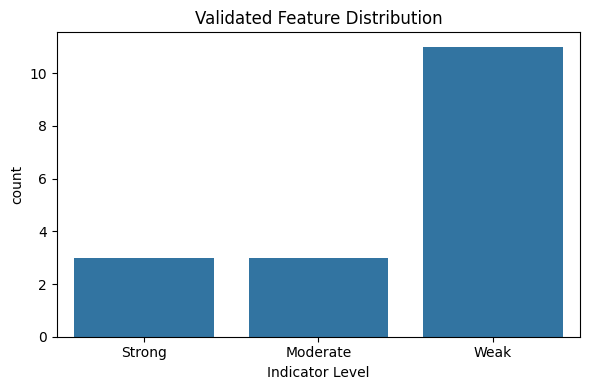

In [46]:
# Trực quan hóa

plt.figure(
    figsize=(6,4)
)

sns.countplot(

    data=feature_validation_summary,
    x="Indicator Level",

    order=[

        "Strong",
        "Moderate",
        "Weak"

    ]

)

plt.title(
    "Validated Feature Distribution"
)

plt.tight_layout()

plt.show()

## 5.3 Final Validated Features

Lựa chọn các đặc trưng được giữ lại để xây dựng mô hình Machine Learning.

In [49]:
validated_features = (

    feature_validation_summary[

        feature_validation_summary["Indicator Level"]
        !=
        "Weak"

    ]

)

# 6. Research Findings

Tóm tắt kết quả của quá trình Feature Validation và xác định tập đặc trưng được sử dụng trong giai đoạn xây dựng mô hình Machine Learning.

In [50]:
# Tổng hợp kết quả Feature Validation

research_findings = pd.DataFrame({

    "Metric": [

        "Total Features",
        "Strong Indicators",
        "Moderate Indicators",
        "Weak Indicators",
        "Validated Features"

    ],

    "Value": [

        len(feature_validation_summary),

        (

            feature_validation_summary["Indicator Level"]
            ==
            "Strong"

        ).sum(),

        (

            feature_validation_summary["Indicator Level"]
            ==
            "Moderate"

        ).sum(),

        (

            feature_validation_summary["Indicator Level"]
            ==
            "Weak"

        ).sum(),

        len(
            validated_features
        )

    ]

})

display(
    research_findings
)

,Metric,Value
0,Total Features,17
1,Strong Indicators,3
2,Moderate Indicators,3
3,Weak Indicators,11
4,Validated Features,6


In [51]:
# Hiển thị các đặc trưng quan trọng nhất

top_features = (

    feature_validation_summary
    .head(
        10
    )

)

display(
    top_features
)

,Rank,Feature,F Score,ANOVA Score,Mutual Information,MI Score,Feature Importance,RF Score,Final Score,Indicator Level
0,1,emotional_exhaustion,710461.5349,100.0000,0.1255,100.0000,0.1372,100.0000,100.0000,Strong
1,2,stress_level,336232.9680,94.1176,0.0665,94.7368,0.0861,94.7368,94.5304,Strong
2,3,daily_screen_time,98228.1097,88.2353,0.0205,84.2105,0.0762,89.4737,87.3065,Strong
3,4,doomscrolling_duration,80691.0372,82.3529,0.0155,68.4211,0.0626,78.9474,76.5738,Moderate
4,5,notification_count,18341.9818,64.7059,0.0044,52.6316,0.0650,84.2105,67.1827,Moderate
5,6,sleep_hours,32805.6649,70.5882,0.0063,63.1579,0.0587,63.1579,65.6347,Moderate
6,7,late_night_device_usage,49958.5748,76.4706,0.0438,89.4737,0.0130,5.2632,57.0691,Weak
7,8,focus_sessions,2.4576,52.9412,0.0054,57.8947,0.0367,36.8421,49.2260,Weak
8,9,deep_work_hours,4122.5818,58.8235,0.0032,26.3158,0.0556,57.8947,47.6780,Weak
9,10,app_switch_frequency,0.7694,35.2941,0.0010,21.0526,0.0598,68.4211,41.5893,Weak


# 7. Export Results

Lưu kết quả Feature Validation để sử dụng cho các notebook tiếp theo.

In [54]:
# Xuất bảng tổng hợp
PROJECT_ROOT = Path.cwd().parents[1]

feature_validation_summary.to_csv(

    PROJECT_ROOT /
    "data" /
    "processed" /
    "international_dataset" /
    "feature_validation_summary.csv",
    index=False

)

validated_features.to_csv(

    PROJECT_ROOT /
    "data" /
    "processed" /
    "international_dataset" /
    "validated_feature_list.csv",
    index=False

)

research_findings.to_csv(

    PROJECT_ROOT /
    "data" /
    "processed" /
    "international_dataset" /
    "feature_validation_findings.csv",
    index=False

)

In [55]:
# Danh sách đặc trưng được giữ lại

selected_features = (
    validated_features["Feature"]
    .tolist()
)

In [58]:
# Xuất bộ dữ liệu đã xác thực

validated_dataset = df[
    selected_features +
    [
        "burnout_score",
        "burnout_risk",
        "productivity_score",
        "productivity_category"
    ]
]

validated_dataset.to_csv(

    PROJECT_ROOT /
    "data" /
    "processed" /
    "international_dataset" /
    "validated_dataset.csv",
    index=False

)

In [59]:
# Chuyển biến mục tiêu sang dạng số 

if df[target_variable].dtype == "object":

    df[target_variable] = (

        df[target_variable]
        .astype("category")
        .cat.codes

    )

In [60]:
# Tổng hợp các tệp đầu ra

output_summary = pd.DataFrame({

    "Output File": [

        "feature_validation_summary.csv",
        "validated_feature_list.csv",
        "feature_validation_findings.csv",
        "validated_dataset.csv"

    ],

    "Description": [

        "Overall feature ranking",
        "Validated feature list",
        "Feature validation summary",
        "Validated dataset"

    ]

})

display(
    output_summary
)

,Output File,Description
0,feature_validation_summary.csv,Overall feature ranking
1,validated_feature_list.csv,Validated feature list
2,feature_validation_findings.csv,Feature validation summary
3,validated_dataset.csv,Validated dataset
